## Задание 1
Увидеть своими глазами чужую реализацию — это одно, а реализовать свою — совершенно другое. Давайте напишем позиционное кодирование с нуля по примеру выше, но с другими параметрами. В этот раз это будет не просто код, но и визуализация, которая покажет, как выглядят позиционные коды. 

Воспроизведите позиционное кодирование  с параметрами `d_model=30`, `seq_len=100`, `batch_size=2`: 
- Используйте `torch.sin` и `torch.cos` для вычисления синусно-косинусных компонент, как показано выше.
- Проверьте, что позиционный код имеет размерность (seq_len, d_model) через принт его размерности.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import math
import torch.nn as nn

d_model = 30
seq_len = 100
batch_size = 2
tokens = torch.randint(0, 10000, (seq_len, batch_size))  # случайные токены
print(tokens.shape)


emb_layer = nn.Embedding(num_embeddings=10000, embedding_dim=d_model)
x = emb_layer(tokens)  # форма (seq_len, batch_size, d_model)
print(x.shape)

torch.Size([100, 2])
torch.Size([100, 2, 30])


In [5]:
# Синусно-косинусное позиционное кодирование
pos = torch.arange(seq_len).unsqueeze(1)  # [[0],[1],...,[seq_len - 1]] 

# Для каждого четного k вычисляем, знаменатель угла,
# который потом пойдет под синус и косинус
k = torch.arange(0, d_model, 2) 
angle_rates = 1 / torch.pow(10000, k / d_model) # размер: (d_model / 2)

# Инициализируем матрицу позиционных кодов нулями
pos_enc = torch.zeros(seq_len, d_model)
# Cчитаем сами позиционные коды через sin и cos 
# для четных и нечетных индексов соответсвнно
pos_enc[:, 0::2] = torch.sin(pos * angle_rates)   # чётные индексы
pos_enc[:, 1::2] = torch.cos(pos * angle_rates)   # нечётные

# повторяем позиционные коды для каждой последовательности из батча
pos_enc = pos_enc.unsqueeze(1).repeat(1, batch_size, 1)  # (seq_len, batch_size, d_model) 
print(pos_enc.shape)

torch.Size([100, 2, 30])


In [8]:
h = x + pos_enc 
print(h.shape)

torch.Size([100, 2, 30])


In [9]:
print(pos_enc)

tensor([[[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
           0.0000e+00,  1.0000e+00],
         [ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
           0.0000e+00,  1.0000e+00]],

        [[ 8.4147e-01,  5.4030e-01,  5.1514e-01,  ...,  1.0000e+00,
           1.8478e-04,  1.0000e+00],
         [ 8.4147e-01,  5.4030e-01,  5.1514e-01,  ...,  1.0000e+00,
           1.8478e-04,  1.0000e+00]],

        [[ 9.0930e-01, -4.1615e-01,  8.8306e-01,  ...,  1.0000e+00,
           3.6957e-04,  1.0000e+00],
         [ 9.0930e-01, -4.1615e-01,  8.8306e-01,  ...,  1.0000e+00,
           3.6957e-04,  1.0000e+00]],

        ...,

        [[ 3.7961e-01, -9.2515e-01,  7.9173e-01,  ...,  9.9945e-01,
           1.7923e-02,  9.9984e-01],
         [ 3.7961e-01, -9.2515e-01,  7.9173e-01,  ...,  9.9945e-01,
           1.7923e-02,  9.9984e-01]],

        [[-5.7338e-01, -8.1929e-01,  3.6391e-01,  ...,  9.9944e-01,
           1.8108e-02,  9.9984e-01],
         [-5.7338e-01, -8.1929e-0

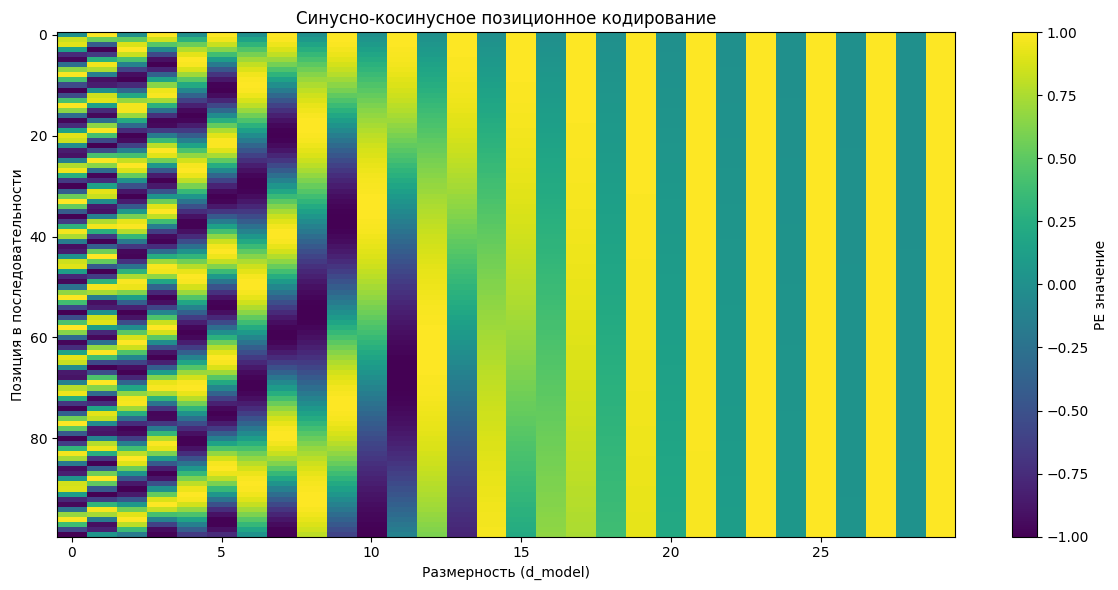

In [11]:
# Визуализация
plt.figure(figsize=(12, 6))
plt.imshow(pos_enc[:, 0, :], aspect='auto', cmap='viridis')
plt.xlabel('Размерность (d_model)')
plt.ylabel('Позиция в последовательности')
plt.title('Синусно-косинусное позиционное кодирование')
plt.colorbar(label='PE значение')
plt.tight_layout()
plt.show()

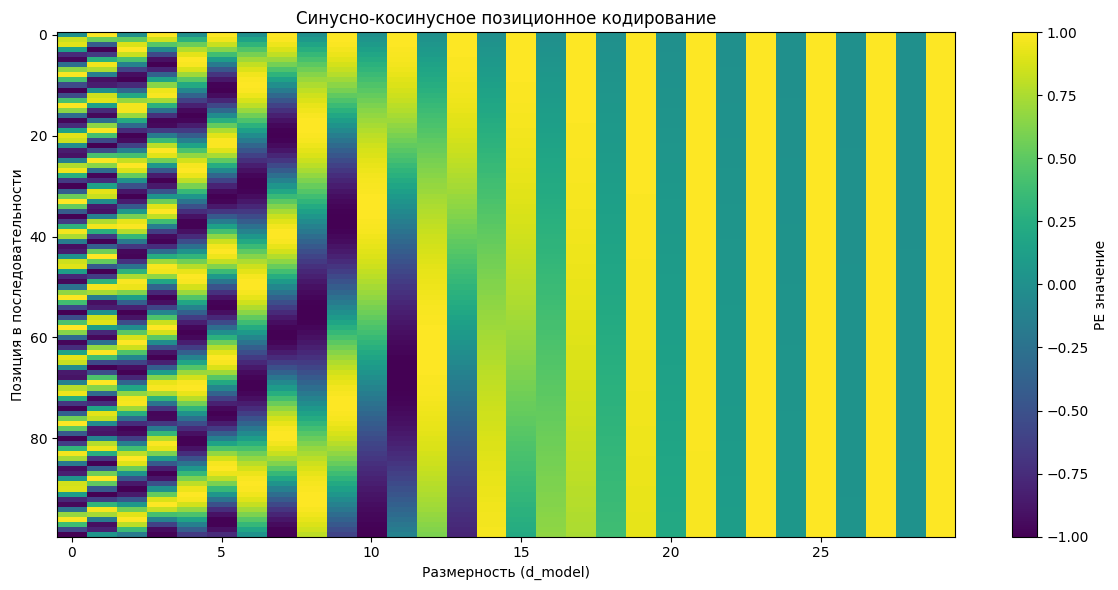

In [12]:
# Визуализация
plt.figure(figsize=(12, 6))
plt.imshow(pos_enc[:, 1, :], aspect='auto', cmap='viridis')
plt.xlabel('Размерность (d_model)')
plt.ylabel('Позиция в последовательности')
plt.title('Синусно-косинусное позиционное кодирование')
plt.colorbar(label='PE значение')
plt.tight_layout()
plt.show()

## Задание 2
- Реализуйте класс `FeedForward` (как выше) и убедитесь, что на выходе форма тензора совпадает с входной 
`(seq_len, batch, d_model)`
- Проверьте это на примере случайного тензора. Инициализируйте блок со значениями `d_model=64`, `dim_ff=256`, а входной тензор сделайте случайным с размерами `seq_len=5`, `batch_size=2`.

In [13]:
import torch
import torch.nn as nn

class FeedForward(nn.Module):
    def __init__(self, d_model, dim_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, dim_ff)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(dim_ff, d_model)
    def forward(self, x):
        # x shape: (seq_len, batch, d_model)
        x = self.linear1(x)   # (seq_len, batch, dim_ff)
        x = self.relu(x)
        x = self.linear2(x)   # (seq_len, batch, d_model)
        return x

# Проверим, что FeedForward не меняет форму тензора
d_model, dim_ff = 64, 256
ff_block = FeedForward(d_model, dim_ff)
seq_len, batch_size = 5, 2
x = torch.randn(seq_len, batch_size, d_model)
y = ff_block(x)
print(x.shape, '->', y.shape)

torch.Size([5, 2, 64]) -> torch.Size([5, 2, 64])


## Задание 3
Чтобы увидеть, как строится encoder block трансформера, и убедиться в том, что он не изменяет форму входного тензора, выполните задание:
1. Реализуйте класс TransformerEncoderBlock с помощью nn.MultiheadAttention и nn.LayerNorm (см. пример выше).
1. Задайте параметры модели d_model=64, num_heads=8, dim_ff=256.
1. Используя случайный входной тензор с размерами seq_len=10, batch_size=2, убедитесь, что выходной тензор имеет ту же форму.

In [15]:

import torch.nn as nn

class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, dim_ff):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, dim_ff)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # x shape: (seq_len, batch_size, d_model)
        attn_out, _ = self.self_attn(x, x, x)     # Multi-Head Attention
        x = self.norm1(x + attn_out)              # Add & Norm
        ff_out = self.ff(x)                       # FeedForward
        x = self.norm2(x + ff_out)               # Add & Norm
        return x 

# Использование блока энкодера:
d_model, num_heads, dim_ff = 64, 8, 256
encoder_block = TransformerEncoderBlock(d_model, num_heads, dim_ff)
x = torch.randn(10, 2, d_model)          # (seq_len=10, batch_size=2, d_model=64)
y = encoder_block(x)
print(y.shape)  # (10, 2, 64)

torch.Size([10, 2, 64])
